## Load .pkl dataset output from filtering code

### Load Filtered DataFrame from .pkl

In [71]:
import pandas as pd

df_posts = pd.read_pickle("./df_posts_filtered.pkl")

### Load Influencers DataFrame from .pkl

This is after we merge influencer-level info (followers, followees) on username, with df_posts, by doing this:
df_posts_influencers = df_posts.merge(
    influencers[["username", "followers", "followees"]],
    on="username",
    how="left"
)

In [72]:
import pandas as pd

df = pd.read_pickle("./df_posts_influencers.pkl")


## Quick view and matching of dataframe contents with previous dataset

In [73]:
df.head()

,user_id,username,publish_timestamp,has_location,is_carousel,num_images,is_sponsored,image_path,caption,likes,comments,followers,followees
0,237173390,15minbeauty,2015-06-18 15:34:41,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,#ad This summer I'm all about keeping my hair ...,39,4,5387,1549
1,237173390,15minbeauty,2015-06-22 12:37:40,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Trying out a ton of great new products right n...,98,0,5387,1549
2,237173390,15minbeauty,2015-07-06 15:33:50,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,I spend a LOT of time and effort to keep my ha...,34,4,5387,1549
3,237173390,15minbeauty,2015-07-29 18:57:55,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"I'm not usually a shadow stick girl, they neve...",31,0,5387,1549
4,237173390,15minbeauty,2015-09-05 17:01:50,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,#ad It's time to get ready for fall manicures ...,35,0,5387,1549


In [74]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100432 entries, 0 to 100431
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            100432 non-null  object
 1   username           100432 non-null  object
 2   publish_timestamp  100432 non-null  object
 3   has_location       100432 non-null  int64 
 4   is_carousel        100432 non-null  int64 
 5   num_images         100432 non-null  int64 
 6   is_sponsored       100432 non-null  int64 
 7   image_path         100432 non-null  object
 8   caption            100432 non-null  object
 9   likes              100432 non-null  int64 
 10  comments           100432 non-null  int64 
 11  followers          97952 non-null   object
 12  followees          97952 non-null   object
dtypes: int64(6), object(7)
memory usage: 10.0+ MB
None


### Show an example image

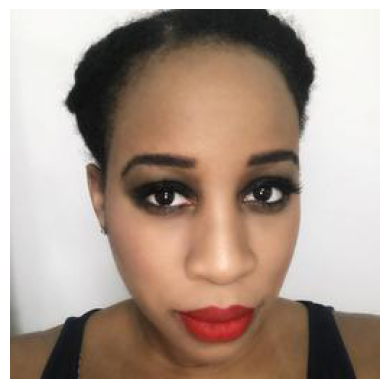

In [75]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def show_random_image(df):
    # pick a random row
    row = df.sample(1).iloc[0]

    # pick a random image from that post
    img_path = random.choice(row["image_path"])

    image = mpimg.imread(img_path)
    plt.imshow(image)
    plt.axis("off")

show_random_image(df)

### Make this dataframe match the previous one from the other dataset

In [76]:
df = df.rename(columns={"followees": "following"})

### Convert datatype for followers and following

In [77]:
df["followers"] = pd.to_numeric(df["followers"], errors="coerce").astype("Int64")
df["following"] = pd.to_numeric(df["following"], errors="coerce").astype("Int64")


### Calculate engagement rate

In [78]:
# engagement_rate = (likes + comments) / max(followers, 1) # avoid division by 0
df["engagement_rate"] = (df["likes"] + df["comments"]) / df["followers"].clip(lower=1) # clip is max(followers, 1)


### Check missing info from influencers.txt

Followers, Following and Engagement Rate had less data than the df_posts dataframe, meaning that some usernames could not be matched in the influencers.txt file (which is the source of followers data)

In [79]:
# Find which usernames cannot be found

df[df["followers"].isna()].sample(10)


,user_id,username,publish_timestamp,has_location,is_carousel,num_images,is_sponsored,image_path,caption,likes,comments,followers,following,engagement_rate
8236,2518223474,ashleighamoroso,2017-05-07 21:10:21,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,with @thefeedfeed and @vitamix i can finally s...,504,18,<NA>,<NA>,<NA>
29533,2026561110,fitkiel,2018-04-04 15:34:37,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Komm doch gern zu uns ins FIT zu deinem ersten...,29,0,<NA>,<NA>,<NA>
41455,553646979,joanijohnson_,2018-10-07 14:14:22,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Sunday Checklist:\nDo nothing and chill \nDo n...,249,13,<NA>,<NA>,<NA>
59809,264409359,monikablunder,2018-11-29 15:18:07,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Holiday glam with #MeganFox #legendofthelost 🎄🎄,1601,38,<NA>,<NA>,<NA>
32553,278531736,gracebeverley,2018-04-20 19:56:04,1,0,1,1,[E:/instagram_dataset_raws/Instagram influence...,Friday feels 🐰\nBack to uni vlog and Pretty Li...,41201,132,<NA>,<NA>,<NA>
8251,2518223474,ashleighamoroso,2018-11-07 19:24:00,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"Let’s be honest, Thanksgiving isn’t just one m...",313,16,<NA>,<NA>,<NA>
22279,14685076,bartdanzig,2018-06-11 16:14:43,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Donut of shame is still on. But I don’t mind a...,4385,118,<NA>,<NA>,<NA>
17118,27986144,curatedbychai,2018-04-30 20:21:44,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,I’m so excited to be re-launching my website a...,305,4,<NA>,<NA>,<NA>
1155,1144090378,her.must,2018-07-04 23:14:47,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,I always come out of the Pool striking a pose....,1744,35,<NA>,<NA>,<NA>
8560,1129498539,ashleyrosereeves,2018-06-08 16:36:26,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,avocado+grapefruit+course salt💥🍊🥑 the recipe i...,854,0,<NA>,<NA>,<NA>


#### Search for username in influencers.txt

In [80]:
import os

# Search for exact username
target_username = "amandamariegray"

# Search in drive containing the original dataset
directory = "E:/instagram_dataset_raws/Instagram influencer dataset/"

influencers_file = os.path.join(directory, "influencers.txt")

with open(influencers_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        if line.startswith(target_username + "\t"):
            print(f"Found at line {i}:")
            print(line)
            break
    else:
        print("No matching line found")


No matching line found


These users are likely not in the influencers.txt. Since we can't make up the followers and following counts that directly form the target label, we will drop these rows.

In [81]:
df = df.dropna(subset=["followers"])


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97952 entries, 0 to 100431
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            97952 non-null  object 
 1   username           97952 non-null  object 
 2   publish_timestamp  97952 non-null  object 
 3   has_location       97952 non-null  int64  
 4   is_carousel        97952 non-null  int64  
 5   num_images         97952 non-null  int64  
 6   is_sponsored       97952 non-null  int64  
 7   image_path         97952 non-null  object 
 8   caption            97952 non-null  object 
 9   likes              97952 non-null  int64  
 10  comments           97952 non-null  int64  
 11  followers          97952 non-null  Int64  
 12  following          97952 non-null  Int64  
 13  engagement_rate    97952 non-null  Float64
dtypes: Float64(1), Int64(2), int64(6), object(5)
memory usage: 11.5+ MB


### Check for duplicates

In [83]:
# Ignore image_path (list of full paths to images)
cols = df.columns.drop("image_path")
df[df.duplicated(subset=cols)]



,user_id,username,publish_timestamp,has_location,is_carousel,num_images,is_sponsored,image_path,caption,likes,comments,followers,following,engagement_rate


No duplicated posts

### Check for improper/odd values

In [84]:
for col in df.columns.drop(["user_id", "username", "publish_timestamp", "image_path", "caption"]):
    print(df[col].value_counts())


has_location
0    53938
1    44014
Name: count, dtype: int64
is_carousel
0    87861
1    10091
Name: count, dtype: int64
num_images
1     87861
2      4558
3      2268
4      1164
5       680
6       421
10      360
7       269
8       207
9       163
16        1
Name: count, dtype: int64
is_sponsored
0    97600
1      352
Name: count, dtype: int64
likes
36        256
39        252
35        252
31        249
40        246
         ... 
3826        1
12577       1
10714       1
10005       1
711300      1
Name: count, Length: 12001, dtype: int64
comments
0       15272
2        4569
1        4480
3        3846
4        3539
        ...  
2175        1
1076        1
2366        1
2782        1
4208        1
Name: count, Length: 1353, dtype: int64
followers
2651     142
1435     133
1101     126
1653     119
1473     114
        ... 
4454       1
24497      1
15205      1
3285       1
1273       1
Name: count, Length: 2421, dtype: Int64
following
995     372
296     237
994     226
404   

The number of images is odd, as Instagram posts before August 2024 had a maximum of 10 images per post, but this dataset was collected in Oct 2018 to Jan 2019, hence num_images should range from 1 to 10.

### num_images check

In [85]:
df[df["num_images"] > 10]


,user_id,username,publish_timestamp,has_location,is_carousel,num_images,is_sponsored,image_path,caption,likes,comments,followers,following,engagement_rate
4307,1963169776,alligoldenphotography,2018-11-08 05:24:25,0,1,16,0,[E:/instagram_dataset_raws/Instagram influence...,We had a little pop up shower come through dur...,15,1,1085,5887,0.014747


Since the actual file really had 13 images, which is not possible in 2018, this is likely an error in data collection. This data will be removed.

In [86]:
df = df[df["num_images"] <= 10]



# Exploratory Data Analysis

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97951 entries, 0 to 100431
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            97951 non-null  object 
 1   username           97951 non-null  object 
 2   publish_timestamp  97951 non-null  object 
 3   has_location       97951 non-null  int64  
 4   is_carousel        97951 non-null  int64  
 5   num_images         97951 non-null  int64  
 6   is_sponsored       97951 non-null  int64  
 7   image_path         97951 non-null  object 
 8   caption            97951 non-null  object 
 9   likes              97951 non-null  int64  
 10  comments           97951 non-null  int64  
 11  followers          97951 non-null  Int64  
 12  following          97951 non-null  Int64  
 13  engagement_rate    97951 non-null  Float64
dtypes: Float64(1), Int64(2), int64(6), object(5)
memory usage: 11.5+ MB


## Followers

### Followers distribution across users

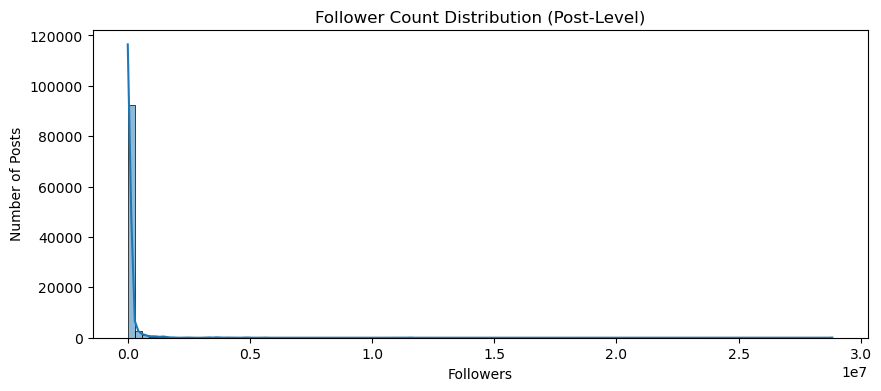

Minimum number of followers: 1001
Maximum number of followers: 28834289
count          97951.0
mean     118824.340629
std      782076.120408
min             1001.0
25%             5043.0
50%            17098.0
75%            52224.0
max         28834289.0
Name: followers, dtype: Float64


In [88]:
import seaborn as sns

# Follower distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['followers'], bins=100, kde=True)
plt.title("Follower Count Distribution (Post-Level)")
plt.xlabel("Followers")
plt.ylabel("Number of Posts")
plt.show()

print(f"Minimum number of followers: {df['followers'].min()}")
print(f"Maximum number of followers: {df['followers'].max()}")
print(df['followers'].describe())

Number of followers is positively skewed, most users have followers in the thousands

### Follower VS engagement rate

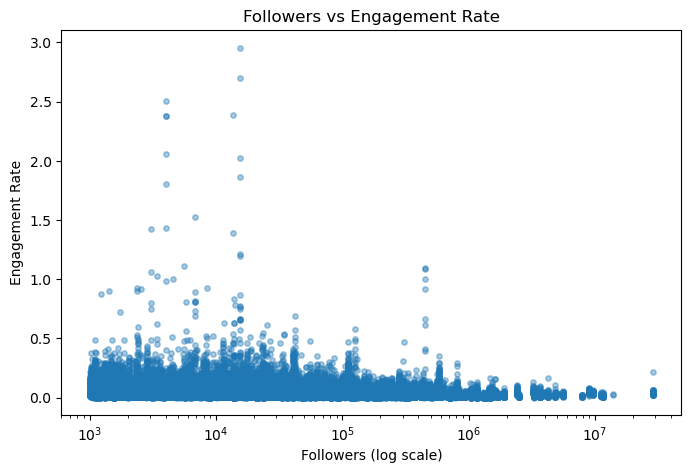

In [89]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['followers'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xscale('log') # log scale on followers due to wide range
plt.xlabel('Followers (log scale)')
plt.ylabel('Engagement Rate')
plt.title('Followers vs Engagement Rate')
plt.show()


Observations:
* Much narrower spread of engagement rate compared to the previous dataset, and more consistent.
* Most posts have low engagement rate regardless of Followers count
* Posts with highest engagement rates have moderate numbers of followers in the thousands or ten thousands. These could be close acquaintances or niche accounts with a close following.
* Posts with lowest engagement rates either have the lowest followers or highest followers.

## Following

### Following count across users

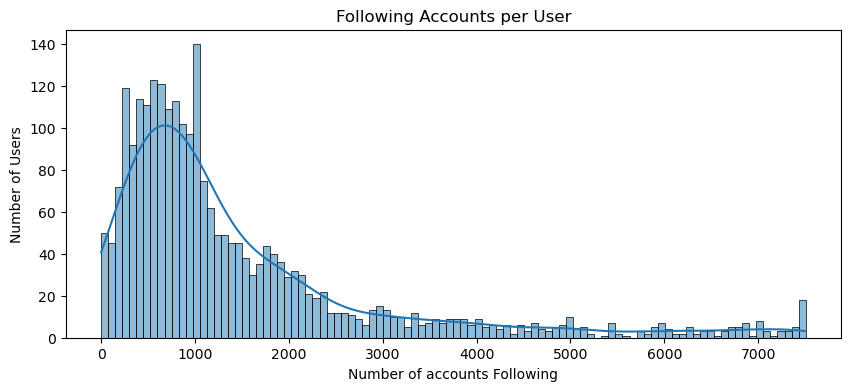

Minimum number of accounts following: 0
Maximum number of accounts following: 7506
count         2510.0
mean     1478.655777
std      1520.630441
min              0.0
25%           542.25
50%            969.5
75%           1810.5
max           7506.0
Name: following, dtype: Float64


In [90]:
# Get max number of accounts following, for each user (in case following count changes in different posts)
user_following = (
    df.groupby('user_id')['following']
      .max()
)

plt.figure(figsize=(10, 4))
sns.histplot(user_following, bins=100, kde=True)
plt.title("Following Accounts per User")
plt.xlabel("Number of accounts Following")
plt.ylabel("Number of Users")
plt.show()

print(f"Minimum number of accounts following: {user_following.min()}")
print(f"Maximum number of accounts following: {user_following.max()}")
print(user_following.describe())

Most accounts followed hundreds to a thousand other accounts.

### Following VS Engagement rate

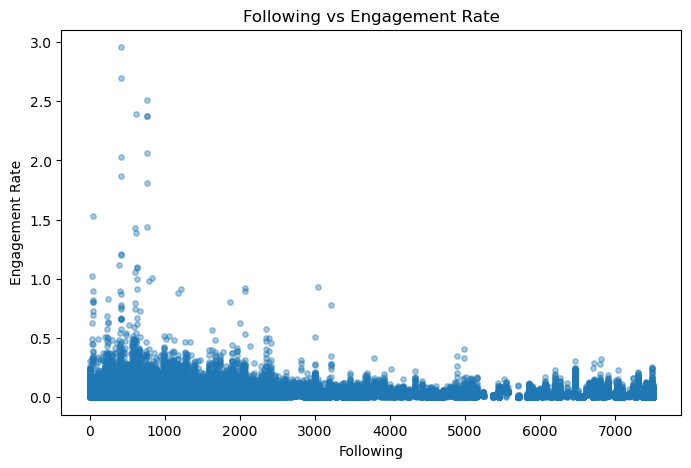

In [91]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['following'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Following')
plt.ylabel('Engagement Rate')
plt.title('Following vs Engagement Rate')
plt.show()

Users with more accounts they were following also had highest engagement rate, possible due to more interaction with other users.

## Followers VS Following

### Follower-following ratio

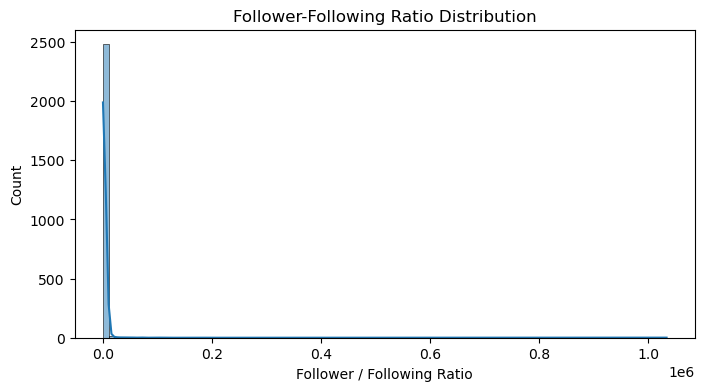

Minimum ratio: 0.14464905257539365
Maximum ratio: 1033364.0
count          2510.0
mean      1280.510395
std      24448.185468
min          0.144649
25%          3.680398
50%         15.151437
75%         74.755834
max         1033364.0
Name: follower_following_ratio, dtype: Float64


In [92]:
df['follower_following_ratio'] = (df['followers'] + 1) / (df['following'] + 1)

# Get max number of accounts following, for each user (in case following count changes in different posts)
user_ff_ratio = (
    df.groupby('user_id')['follower_following_ratio']
      .max()
)

plt.figure(figsize=(8, 4))
sns.histplot(user_ff_ratio, bins=100, kde=True)
plt.xlabel('Follower / Following Ratio')
plt.title('Follower-Following Ratio Distribution')
plt.show()

print(f"Minimum ratio: {user_ff_ratio.min()}")
print(f"Maximum ratio: {user_ff_ratio.max()}")
print(user_ff_ratio.describe())

Most users have much more accounts they are following, than followers.

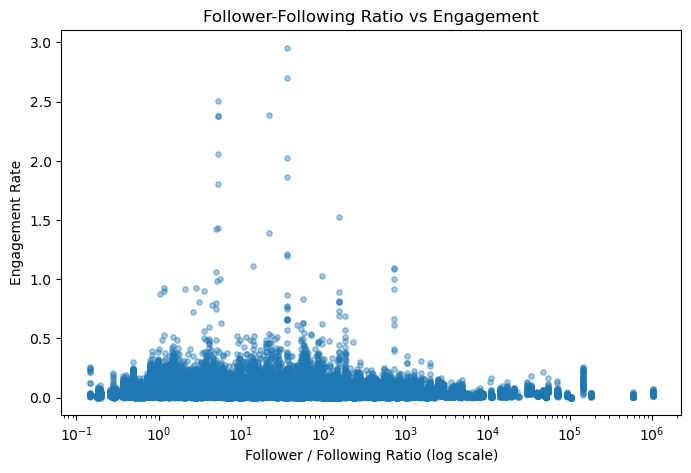

In [93]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['follower_following_ratio'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xscale('log')
plt.xlabel('Follower / Following Ratio (log scale)')
plt.ylabel('Engagement Rate')
plt.title('Follower-Following Ratio vs Engagement')
plt.show()


Posts with higher follower count than following count also had higher engagement rate.

C:\Users\sugar\AppData\Local\Temp\ipykernel_92728\3841241095.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ratio_bin')['engagement_rate'].median().plot(kind='bar')


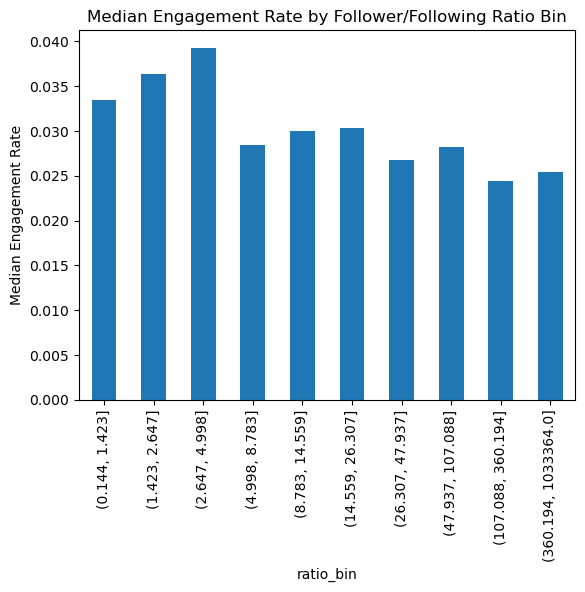

In [94]:
df['ratio_bin'] = pd.qcut(df['follower_following_ratio'], q=10)

df.groupby('ratio_bin')['engagement_rate'].median().plot(kind='bar')
plt.ylabel('Median Engagement Rate')
plt.title('Median Engagement Rate by Follower/Following Ratio Bin')
plt.show()


Users with 2x to 4x the number of followers than following have higher median engagement rates

While scatter plots suggested occasional high engagement for posts from low follower–following ratio accounts, binned median analysis revealed that high-ratio accounts achieved higher typical engagement. This indicates higher variance among low-ratio accounts and more consistent engagement among high-ratio accounts.

In [95]:
df = df.drop(columns=['ratio_bin'])

## Publish timestamp (UTC) -> Hour and Day of post, weekend flag

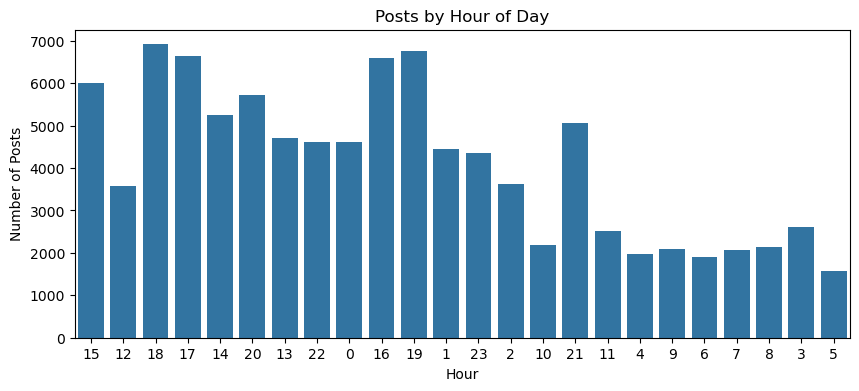

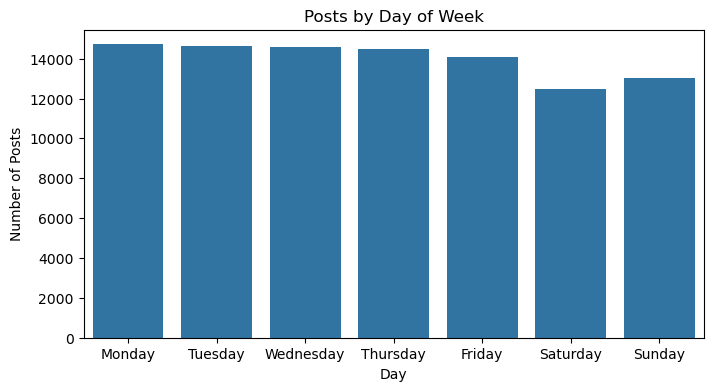

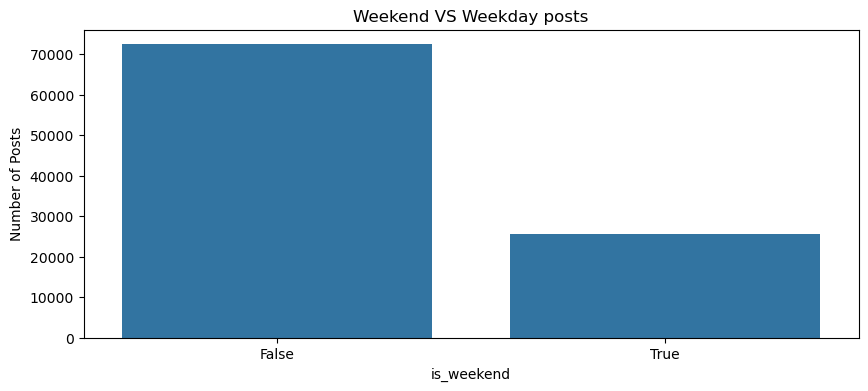

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to datetime
df['publish_timestamp'] = pd.to_datetime(df['publish_timestamp'], errors='coerce')

# Extract post hour and day
df['hour'] = df['publish_timestamp'].dt.hour.astype(str)
df['day'] = df['publish_timestamp'].dt.day_name()

# Extract weekend flag from post day
df['is_weekend'] = df['day'].isin(['Saturday', 'Sunday'])

# Hourly posting pattern
plt.figure(figsize=(10, 4))
sns.countplot(x='hour', data=df)
plt.title("Posts by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Posts")
plt.show()

# Daily pattern
plt.figure(figsize=(8, 4))
sns.countplot(x='day', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Posts by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Posts")
plt.show()

# Weekend vs weekday
plt.figure(figsize=(10, 4))
sns.countplot(x='is_weekend', data=df)
plt.title("Weekend VS Weekday posts")
plt.xlabel("is_weekend")
plt.ylabel("Number of Posts")
plt.show()

### Likes and comments per hour

Minimum likes: 0
Maximum likes: 5733212
Minimum comments: 0
Maximum comments: 420680


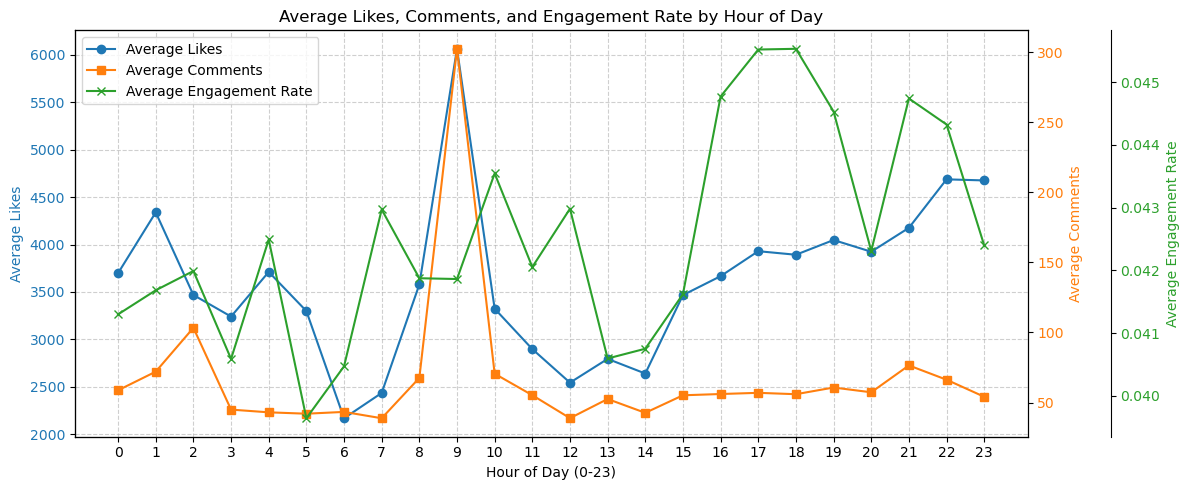

In [97]:
# Group by hour
df['hour'] = df['hour'].astype(int)

hourly_stats = df.groupby('hour')[['likes', 'comments', 'engagement_rate']].mean()

print(f"Minimum likes: {df['likes'].min()}")
print(f"Maximum likes: {df['likes'].max()}")
print(f"Minimum comments: {df['comments'].min()}")
print(f"Maximum comments: {df['comments'].max()}")

fig, ax1 = plt.subplots(figsize=(12, 5))

# Likes (left y-axis)
color_likes = 'tab:blue'
ax1.plot(
    hourly_stats.index,
    hourly_stats['likes'],
    marker='o',
    label='Average Likes',
    color=color_likes
)
ax1.set_xlabel('Hour of Day (0-23)')
ax1.set_ylabel('Average Likes', color=color_likes)
ax1.tick_params(axis='y', labelcolor=color_likes)
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle='--', alpha=0.6)

# Comments (right y-axis)
color_comments = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(
    hourly_stats.index,
    hourly_stats['comments'],
    marker='s',
    label='Average Comments',
    color=color_comments
)
ax2.set_ylabel('Average Comments', color=color_comments)
ax2.tick_params(axis='y', labelcolor=color_comments)

# Engagement rate (second right y-axis, offset)
color_engagement = 'tab:green'
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(
    hourly_stats.index,
    hourly_stats['engagement_rate'],
    marker='x',
    label='Average Engagement Rate',
    color=color_engagement
)
ax3.set_ylabel('Average Engagement Rate', color=color_engagement)
ax3.tick_params(axis='y', labelcolor=color_engagement)

# Combined legend
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Average Likes, Comments, and Engagement Rate by Hour of Day')
plt.tight_layout()
plt.show()


* Note: Hour of Day is in UTC time, and since the timezone of the posts is not shown, the observations may not be reliable
* The average engagement rate peaks at 9-11AM and after 3PM, which could roughly coincide with working hours, but again this may not be reliable.

### Likes and comments per day

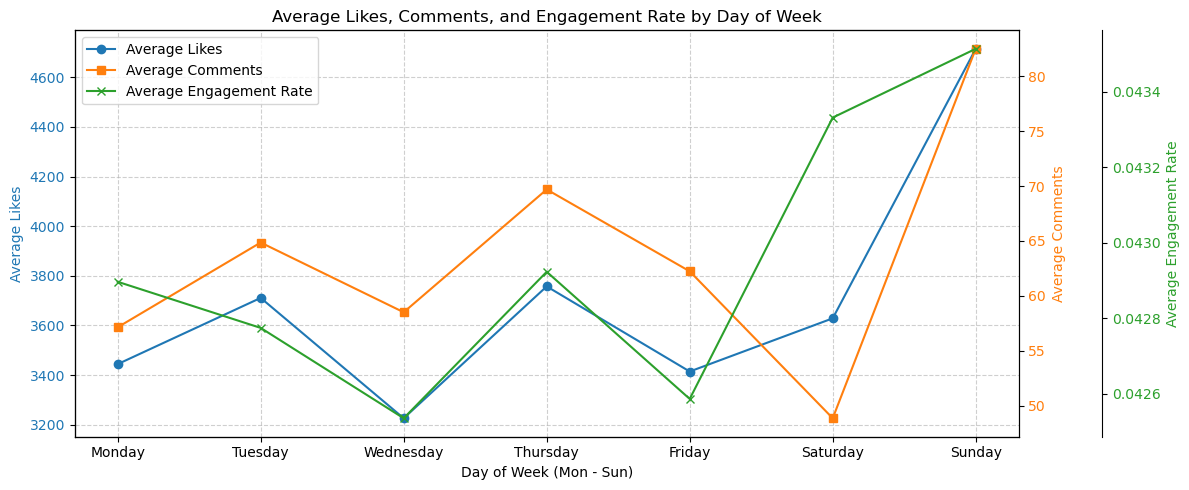

In [98]:
# Set weekday order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day
daily_stats = df.groupby('day')[['likes', 'comments', 'engagement_rate']].mean().reindex(days_order)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Likes (left y-axis)
color_likes = 'tab:blue'
ax1.plot(
    daily_stats.index,
    daily_stats['likes'],
    marker='o',
    label='Average Likes',
    color=color_likes
)
ax1.set_xlabel('Day of Week (Mon - Sun)')
ax1.set_ylabel('Average Likes', color=color_likes)
ax1.tick_params(axis='y', labelcolor=color_likes)
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle='--', alpha=0.6)

# Comments (right y-axis)
color_comments = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(
    daily_stats.index,
    daily_stats['comments'],
    marker='s',
    label='Average Comments',
    color=color_comments
)
ax2.set_ylabel('Average Comments', color=color_comments)
ax2.tick_params(axis='y', labelcolor=color_comments)

# Engagement rate (second right y-axis, offset)
color_engagement = 'tab:green'
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(
    daily_stats.index,
    daily_stats['engagement_rate'],
    marker='x',
    label='Average Engagement Rate',
    color=color_engagement
)
ax3.set_ylabel('Average Engagement Rate', color=color_engagement)
ax3.tick_params(axis='y', labelcolor=color_engagement)

# Combined legend
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Average Likes, Comments, and Engagement Rate by Day of Week')
plt.tight_layout()
plt.show()

* Average likes, and engagement rates peak on Sunday (same pattern shown in the previous dataset)
* Average comments peak on Wednesday and Friday

## Binary features (has_location, is_carousel)
is_sponsored is plotted after captions processed

### has_location

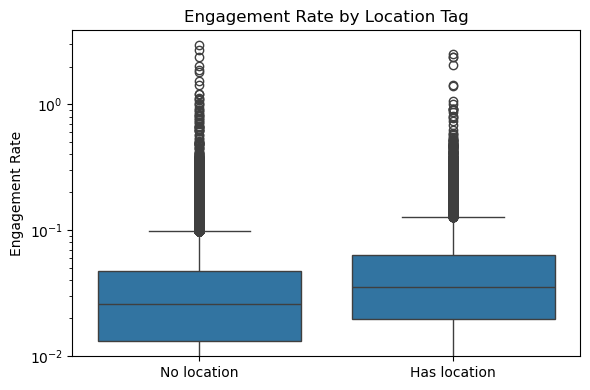

In [99]:
plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    x='has_location',
    y='engagement_rate',
    data=df,
    order=[0, 1]
)
ax.set_yscale('log') # for visibility of box plot
ax.set_xticks([0, 1])
ax.set_xticklabels(['No location', 'Has location'])
plt.xlabel('')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by Location Tag')
plt.tight_layout()
plt.show()


* Median engagement rate is below 0 whether or not Location information in included in the post.
* Since engagement rate is (likes + comments) / followers,
* this means followers is always greater than likes + comments, no new audiences reached. This makes sense.
* When location information is included, the engagement rate has slightly higher median.
* This also makes sense because other people who are not followers can find these posts by location.

### is_carousel

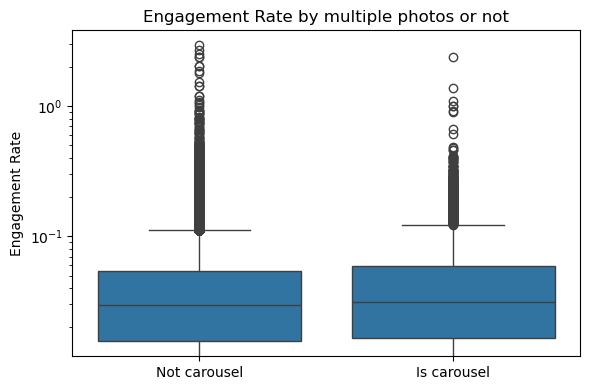

In [100]:
plt.figure(figsize=(6, 4))
ax=sns.boxplot(
    x='is_carousel',
    y='engagement_rate',
    data=df,
    order=[0, 1]
)
ax.set_yscale('log') # for visibility of box plot
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not carousel', 'Is carousel'])
plt.xlabel('')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by multiple photos or not')
plt.tight_layout()
plt.show()


* Median engagement rate is below 0 whether or not the post is a carousel or not.
* Since engagement rate is (likes + comments) / followers,
* this means followers is always greater than likes + comments, no new audiences reached. This makes sense.

## Captions

### Word count in caption

In [101]:
import pandas as pd
import re

def clean_caption_no_hashtag(text):
    if not isinstance(text, str):
        return ""

    # remove hashtags anywhere in text (followed by word characters until it hits non-word)
    text = re.sub(r"#\w+", "", text)

    # replace newlines with space
    text = text.replace('\n', ' ')

    # normalize spacing
    text = re.sub(r"\s+", " ", text)

    return text.strip().lower()

df['clean_caption'] = df['caption'].apply(clean_caption_no_hashtag)
df['caption_word_count'] = df['caption'].apply(lambda x: len(clean_caption_no_hashtag(x).split()))

# df['caption_word_count'] = df['caption'].apply(clean_caption_no_hashtag)
df[['clean_caption', 'caption_word_count']].head()

,clean_caption,caption_word_count
0,this summer i'm all about keeping my hair up a...,37
1,trying out a ton of great new products right n...,47
2,i spend a lot of time and effort to keep my ha...,44
3,"i'm not usually a shadow stick girl, they neve...",43
4,it's time to get ready for fall manicures with...,29


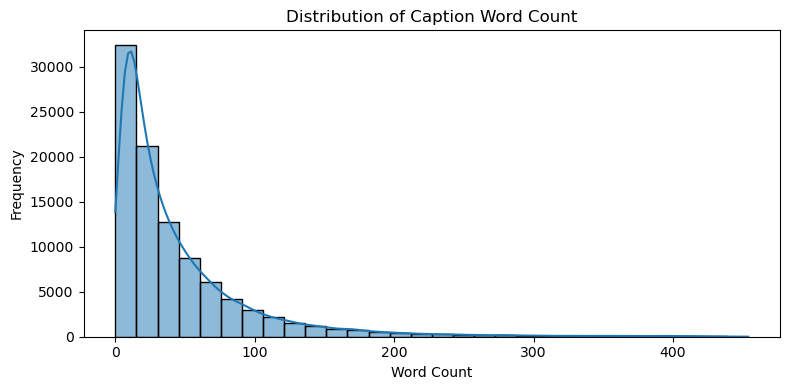

Minimum caption word count: 0
Maximum caption word count: 454
Median caption word count: 26.0
count    97951.000000
mean        44.827883
std         53.495876
min          0.000000
25%         12.000000
50%         26.000000
75%         57.000000
max        454.000000
Name: caption_word_count, dtype: float64


In [102]:
plt.figure(figsize=(8,4))
sns.histplot(df['caption_word_count'], bins=30, kde=True)
plt.title('Distribution of Caption Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Minimum caption word count: {df['caption_word_count'].min()}")
print(f"Maximum caption word count: {df['caption_word_count'].max()}")
print(f"Median caption word count: {df['caption_word_count'].median()}")
print(df['caption_word_count'].describe())


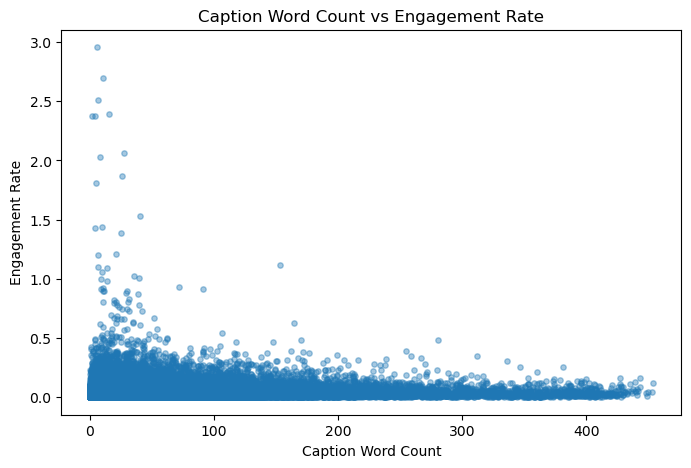

In [103]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['caption_word_count'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Caption Word Count')
plt.ylabel('Engagement Rate')
plt.title('Caption Word Count vs Engagement Rate')
plt.show()

* Most captions are very short, less than 50 words. 
* Posts with the highest engagement rate also had very short captions.

### Extract hashtags from caption
Also add flag for whether post contains hashtags, and if any posts are clearly ads using the #ads hashtag

In [104]:
# Add list of hashtags as new feature
df["hashtags"] = (
    df["caption"]
    .str.lower()
    .str.findall(r"#\w+")
    .apply(lambda tags: [t[1:] for t in tags])
)

# Add feature for number of hashtags
df["num_hashtags"] = df["hashtags"].apply(len)


In [105]:
(ad := "ad") in df["hashtags"].explode().values
df["hashtags"].apply(lambda tags: "ad" in tags).sum()


np.int64(3914)

### Re-label posts as is_sponsored=1 
if post is already sponsored (from metadata), or contains sponsorship-related hashtags (e.g., #ad, #sponsored, #paidAd). This is in line with the sponsorship labelling conducted by the dataset owner.

In [106]:
# Check if any posts are clearly ads using the #ad, #sponsored, #paidad hashtag
ad_tags = {"ad", "ads", "sponsored", "paidad"}

df["ads"] = df["hashtags"].apply(
    lambda tags: any(tag in ad_tags for tag in tags)
)


In [107]:
df["ads"].value_counts()

ads
False    93178
True      4773
Name: count, dtype: int64

In [108]:
df["is_sponsored"].value_counts()

is_sponsored
0    97599
1      352
Name: count, dtype: int64

In [109]:
df["is_sponsored"] = (
    df["ads"] | (df["is_sponsored"] == 1)
).astype(int)

In [110]:
df["is_sponsored"].value_counts()

is_sponsored
0    93019
1     4932
Name: count, dtype: int64

### is_sponsored

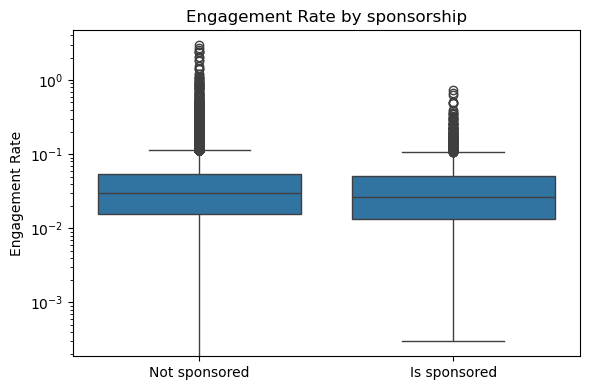

In [111]:
plt.figure(figsize=(6, 4))
ax=sns.boxplot(
    x='is_sponsored',
    y='engagement_rate',
    data=df,
    order=[0, 1]
)
ax.set_yscale('log') # for visibility of box plot
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not sponsored', 'Is sponsored'])
plt.xlabel('')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by sponsorship')
plt.tight_layout()
plt.show()

* Median engagement rate is below 0 whether or not the post is sponsored.
* Since engagement rate is (likes + comments) / followers,
* this means followers is always greater than likes + comments, no new audiences reached. This makes sense.
* Non-sponsored posts have a much wider range in engagement rate, and likes + comments can exceed follower count.
* Sponsored posts have slightly lower median engagement rate and lower 25th percentile engagement rate, suggesting that audiences dislike sponsored posts.

In [112]:
df = df.drop(columns=['ads'])

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97951 entries, 0 to 100431
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   97951 non-null  object        
 1   username                  97951 non-null  object        
 2   publish_timestamp         97951 non-null  datetime64[ns]
 3   has_location              97951 non-null  int64         
 4   is_carousel               97951 non-null  int64         
 5   num_images                97951 non-null  int64         
 6   is_sponsored              97951 non-null  int64         
 7   image_path                97951 non-null  object        
 8   caption                   97951 non-null  object        
 9   likes                     97951 non-null  int64         
 10  comments                  97951 non-null  int64         
 11  followers                 97951 non-null  Int64         
 12  following             

### Number of hashtags

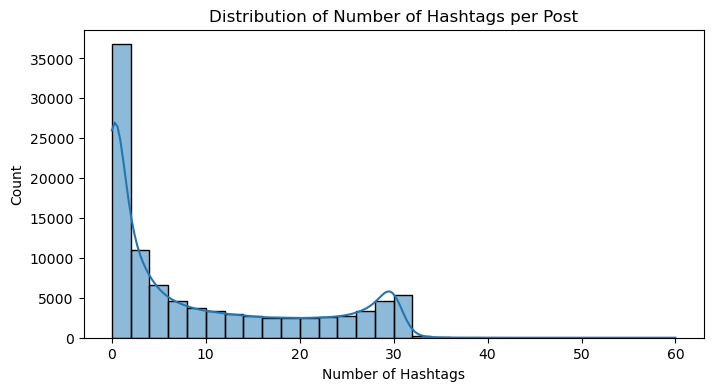

Minimum number of hashtags: 0
Maximum number of hashtags: 60
count    97951.000000
mean         9.094251
std         10.467091
min          0.000000
25%          0.000000
50%          4.000000
75%         17.000000
max         60.000000
Name: num_hashtags, dtype: float64


In [114]:
plt.figure(figsize=(8,4))
sns.histplot(df["num_hashtags"], bins=30, kde=True)
plt.title("Distribution of Number of Hashtags per Post")
plt.xlabel("Number of Hashtags")
plt.ylabel("Count")
plt.show()

print(f"Minimum number of hashtags: {df['num_hashtags'].min()}")
print(f"Maximum number of hashtags: {df['num_hashtags'].max()}")
print(df['num_hashtags'].describe())

Interestingly many posts have 30 hashtags. 50% of posts have 4 or fewer hashtags

### Engagement rate VS number of hashtags

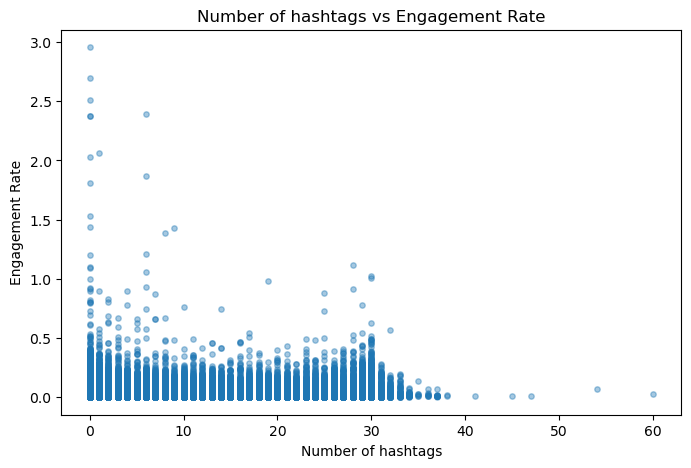

In [115]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['num_hashtags'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Number of hashtags')
plt.ylabel('Engagement Rate')
plt.title('Number of hashtags vs Engagement Rate')
plt.show()

The posts with highest engagement rate have either low number of hashtags, or 30 hashtags.

## Number of Images

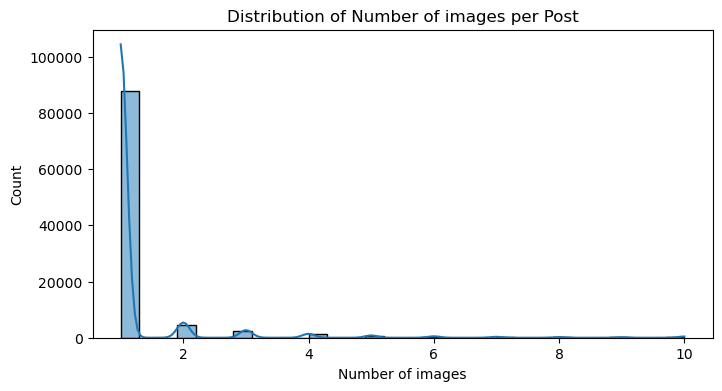

Minimum number of images: 1
Maximum number of images: 10
count    97951.000000
mean         1.255413
std          1.003008
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: num_images, dtype: float64


In [116]:
plt.figure(figsize=(8,4))
sns.histplot(df["num_images"], bins=30, kde=True)
plt.title("Distribution of Number of images per Post")
plt.xlabel("Number of images")
plt.ylabel("Count")
plt.show()

print(f"Minimum number of images: {df['num_images'].min()}")
print(f"Maximum number of images: {df['num_images'].max()}")
print(df['num_images'].describe())

Most posts have 1 image

### Engagement rate VS number of images

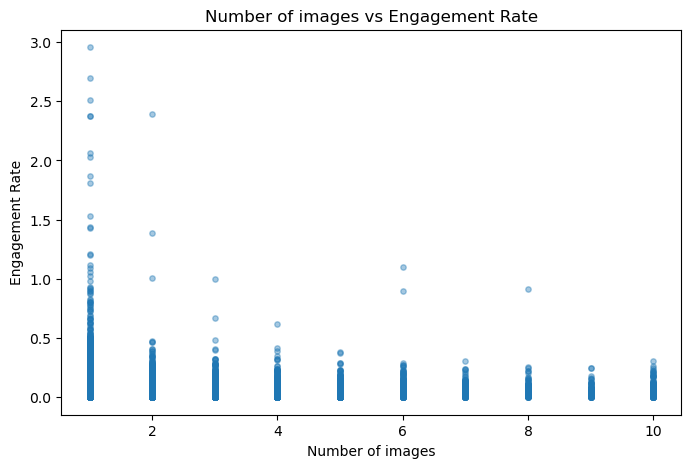

Minimum number of images: 1
Maximum number of images: 10


In [117]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['num_images'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Number of images')
plt.ylabel('Engagement Rate')
plt.title('Number of images vs Engagement Rate')
plt.show()

print(f"Minimum number of images: {df['num_images'].min()}")
print(f"Maximum number of images: {df['num_images'].max()}")

The number of images does not affect the engagement rate. The posts with highest engagement rate only have 1 image.

## Engagement rate

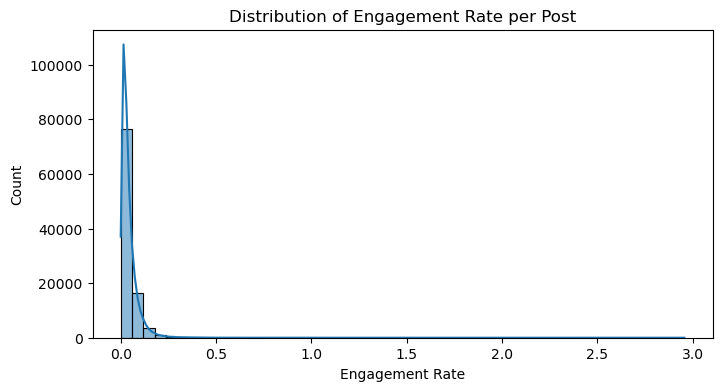

Minimum Engagement Rate: 0.0
Maximum Engagement Rate: 2.956668835393624
count     97951.0
mean     0.042922
std      0.052338
min           0.0
25%      0.015664
50%      0.029901
75%      0.054267
max      2.956669
Name: engagement_rate, dtype: Float64


In [118]:
plt.figure(figsize=(8,4))
sns.histplot(df["engagement_rate"], bins=50, kde=True)
plt.title("Distribution of Engagement Rate per Post")
plt.xlabel("Engagement Rate")
plt.ylabel("Count")
plt.show()

print(f"Minimum Engagement Rate: {df['engagement_rate'].min()}")
print(f"Maximum Engagement Rate: {df['engagement_rate'].max()}")
print(df['engagement_rate'].describe())

In [119]:
df["engagement_rate"].quantile(0.66)

np.float64(0.04301693266722667)

## Class engagement rate into bins

In [124]:

# Quantile-based classes
low = df["engagement_rate"].quantile(0.33)
high = df["engagement_rate"].quantile(0.66)
print(low)
print(high)

def label_engagement(x, low, high):
    if x <= low:
        return 0  # low
    elif x <= high:
        return 1  # medium
    else:
        return 2  # high

# Label by quantile
df["engagement_label"] = df["engagement_rate"].apply(label_engagement, args=(low, high))

# Label by benchmark ranges 
# df["engagement_label"] = df["engagement_rate"].apply(label_engagement, args=(0.5, 1))


0.019834710743801654
0.04301693266722667


If we bin by benchmark ranges, there are no datapoints with >3.5% engagement rate

Even with an arbitrary separation at 0.5% and 1%, the distribution is extremely imbalanced:

|engagement_label| count |
|---|---|
0   | 97874
1   |    54
2    |    23


In [125]:
df["engagement_label"].value_counts()

engagement_label
2    33303
0    32327
1    32321
Name: count, dtype: int64

### Followers VS following, by engagement label

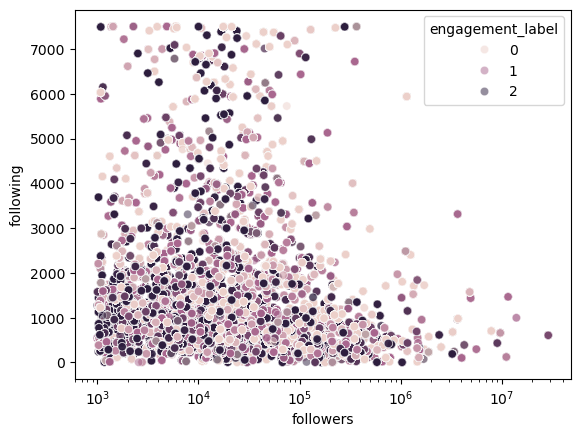

In [126]:
sns.scatterplot(
    x='followers',
    y='following',
    hue=df["engagement_label"],
    data=df,
    alpha=0.5
)
plt.xscale('log')
plt.show()

Posts with the lowest engagement rates had moderate number of followers and a range of number of accounts following.

# Drop features used to make final target label to avoid leakage

In [127]:
df = df.drop(columns=["likes","comments","engagement_rate","followers"])

To prevent target leakage, features directly involved in the computation of engagement labels, including likes, comments, and engagement rate, were excluded from the model inputs. Follower count was also omitted to avoid mathematical coupling with the target.

# Feature interactions

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97951 entries, 0 to 100431
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   97951 non-null  object        
 1   username                  97951 non-null  object        
 2   publish_timestamp         97951 non-null  datetime64[ns]
 3   has_location              97951 non-null  int64         
 4   is_carousel               97951 non-null  int64         
 5   num_images                97951 non-null  int64         
 6   is_sponsored              97951 non-null  int64         
 7   image_path                97951 non-null  object        
 8   caption                   97951 non-null  object        
 9   following                 97951 non-null  Int64         
 10  follower_following_ratio  97951 non-null  Float64       
 11  hour                      97951 non-null  int64         
 12  day                   

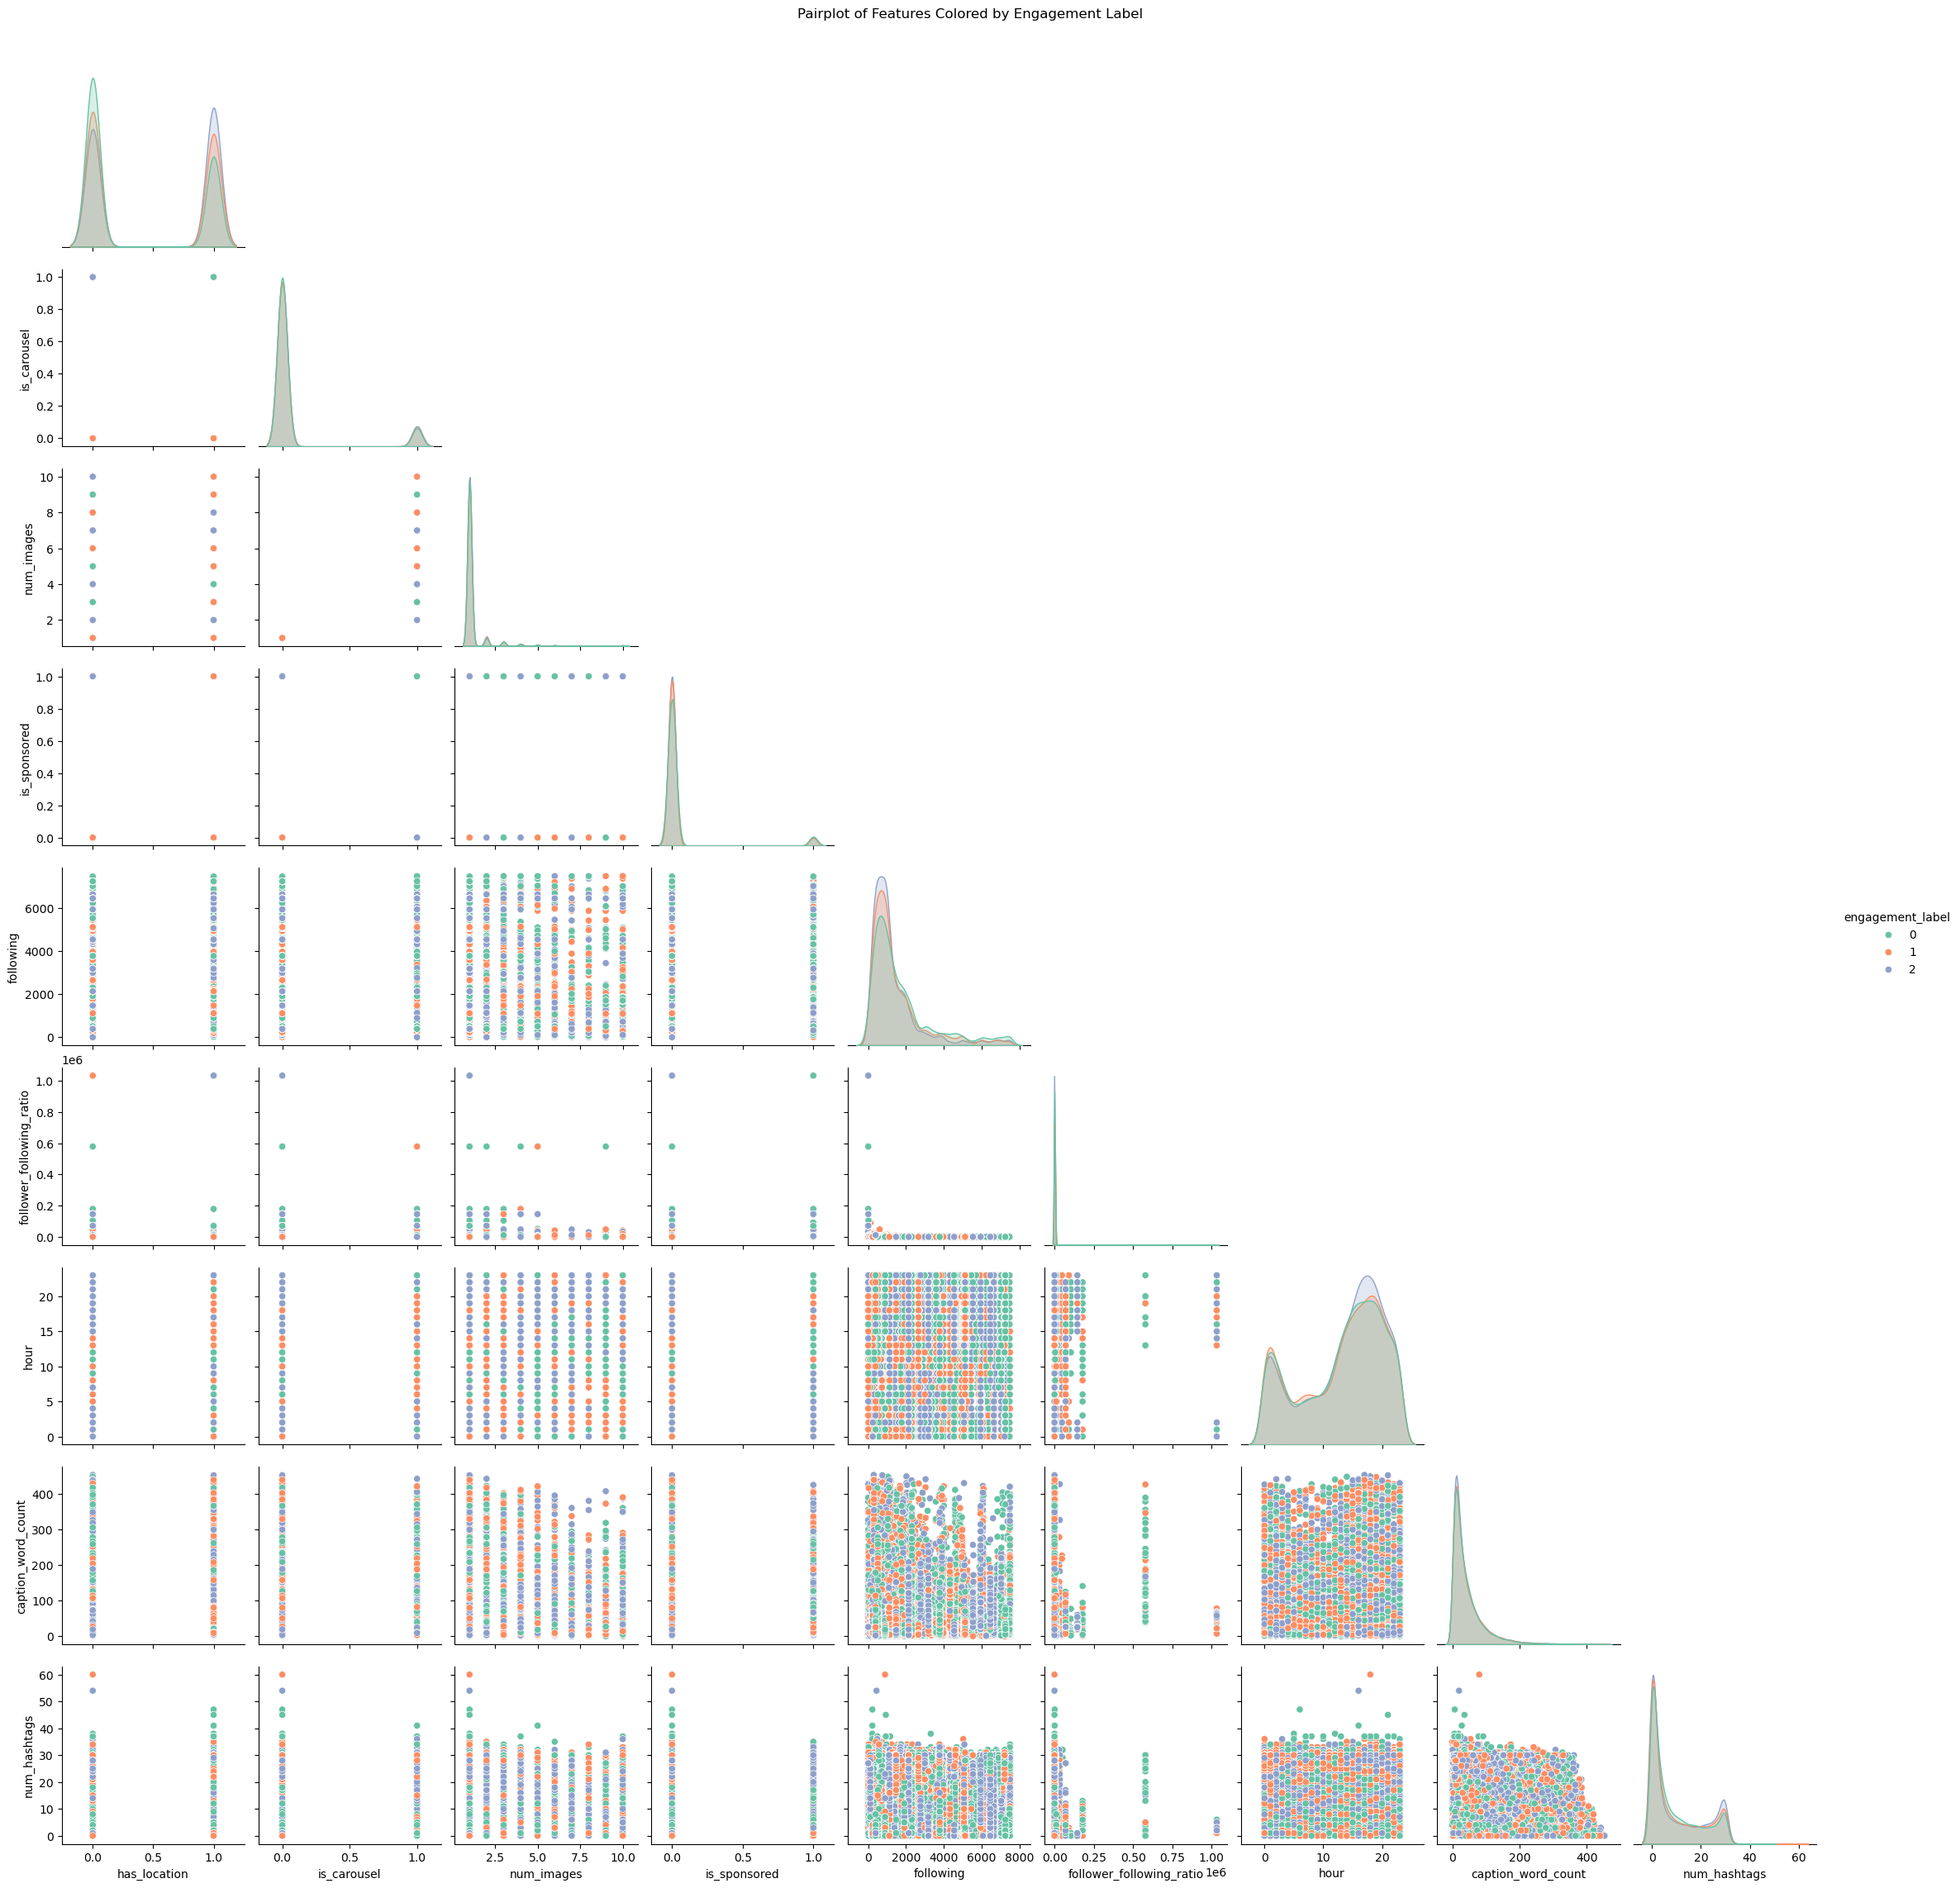

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get numeric columns including engagement_label
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Pairplot
hue_labels = {0: "Low", 1: "Medium", 2: "High"}
sns.pairplot(df[numeric_cols], hue="engagement_label",
             palette="Set2", diag_kind="kde", corner=True)

plt.suptitle("Pairplot of Features Colored by Engagement Label", y=1.02)
plt.show()



Looking at the pairplots, there are no clear interactions between the features to form higher/lower engagement rates. This is shown from the mix in engagement labels across the plot.

# Data processing

## Train test split

Data was split temporally within each user, using earlier posts for training and later posts for testing to simulate real-world post evaluation.

In [137]:
df = df.sort_values(["user_id", "publish_timestamp"])

def temporal_split(group, train_frac=0.8):
    split_idx = int(len(group) * train_frac)
    return group.iloc[:split_idx], group.iloc[split_idx:]

train_parts = []
test_parts = []

for _, g in df.groupby("user_id"):
    if len(g) >= 3:  # avoid tiny histories
        tr, te = temporal_split(g)
        train_parts.append(tr)
        test_parts.append(te)

train_df = pd.concat(train_parts)
test_df  = pd.concat(test_parts)


#### 1. Check that there is no future leakage within each user

In [138]:
violations = []

for user_id in train_df['user_id'].unique():
    train_times = train_df.loc[train_df['user_id'] == user_id, 'publish_timestamp']
    test_times  = test_df.loc[test_df['user_id'] == user_id, 'publish_timestamp']

    if not test_times.empty:
        if train_times.max() > test_times.min():
            violations.append(user_id)

len(violations)


0

#### 2. Check that each user appears in both sets

In [139]:
common_users = set(train_df['user_id']) & set(test_df['user_id'])

len(common_users), train_df['user_id'].nunique(), test_df['user_id'].nunique()

(2420, 2420, 2420)


#### 3. Check label distribution for class imbalance (should be around 33% each)

In [140]:
def label_dist(df, name):
    print(f"\n{name} label distribution:")
    print(df['engagement_label'].value_counts(normalize=True))

label_dist(train_df, "Train")
label_dist(test_df, "Test")



Train label distribution:
engagement_label
0    0.339598
1    0.335048
2    0.325354
Name: proportion, dtype: float64

Test label distribution:
engagement_label
2    0.396077
1    0.310459
0    0.293464
Name: proportion, dtype: float64


#### 4. Check that each user has enough history

In [141]:

min_posts_train = train_df.groupby("user_id").size().min()
min_posts_test  = test_df.groupby("user_id").size().min()

min_posts_train, min_posts_test


(2, 1)

#### Pick random user to check split

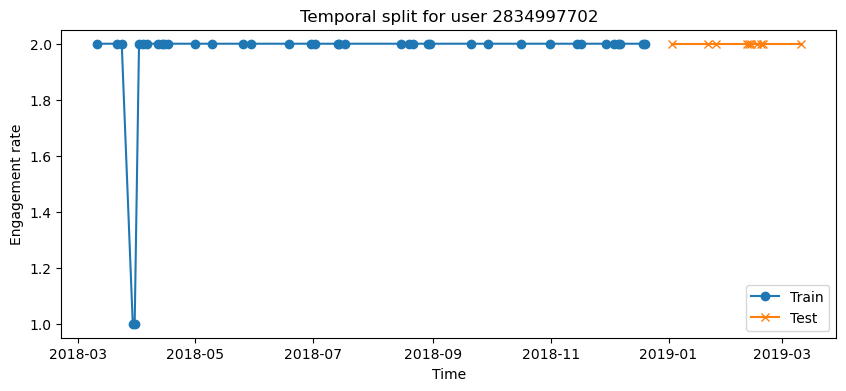

In [142]:
import matplotlib.pyplot as plt
import numpy as np

user = np.random.choice(train_df['user_id'].unique())

plt.figure(figsize=(10,4))

plt.plot(
    train_df[train_df['user_id'] == user]['publish_timestamp'],
    train_df[train_df['user_id'] == user]['engagement_label'],
    label='Train', marker='o'
)

plt.plot(
    test_df[test_df['user_id'] == user]['publish_timestamp'],
    test_df[test_df['user_id'] == user]['engagement_label'],
    label='Test', marker='x'
)

plt.title(f"Temporal split for user {user}")
plt.xlabel("Time")
plt.ylabel("Engagement rate")
plt.legend()
plt.show()


In [143]:
assert train_df[train_df['user_id'] == user]['publish_timestamp'].max() < test_df[test_df['user_id'] == user]['publish_timestamp'].min()


# Export split data

In [144]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77574 entries, 27848 to 54032
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   77574 non-null  object        
 1   username                  77574 non-null  object        
 2   publish_timestamp         77574 non-null  datetime64[ns]
 3   has_location              77574 non-null  int64         
 4   is_carousel               77574 non-null  int64         
 5   num_images                77574 non-null  int64         
 6   is_sponsored              77574 non-null  int64         
 7   image_path                77574 non-null  object        
 8   caption                   77574 non-null  object        
 9   following                 77574 non-null  Int64         
 10  follower_following_ratio  77574 non-null  Float64       
 11  hour                      77574 non-null  int64         
 12  day                

In [145]:
if not os.path.exists('data'):
    os.makedirs('data')

train_df.to_csv("data/train_df.csv", index=False)
test_df.to_csv("data/test_df.csv", index=False)
